In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import KFold

PROCESSED_DIR = Path("data/processed")
TABLES_DIR = Path("outputs/tables")
FIGURES_DIR = Path("outputs/figures")
MODELS_DIR = Path("outputs/models")

for folder in [TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

priced = pd.read_csv(PROCESSED_DIR / "pokemon_priced_features.csv", low_memory=False)
unpriced = pd.read_csv(PROCESSED_DIR / "pokemon_unpriced_features.csv", low_memory=False)
features = pd.read_csv(TABLES_DIR / "final_model_features.csv")["feature"].tolist()
full_model = joblib.load(MODELS_DIR / "final_lightgbm_full_model.joblib")

X = priced[features]
y = priced["Log_Value"]
X_unpriced = unpriced[features]

predicted_log = full_model.predict(X_unpriced)
predicted_value = np.maximum(np.expm1(predicted_log), 0)

C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [2]:
folds = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = np.zeros(len(priced))
fold_id = np.zeros(len(priced), dtype=int)

for fold, (train_idx, val_idx) in enumerate(folds.split(X), 1):
    model = clone(full_model)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    oof_pred[val_idx] = model.predict(X.iloc[val_idx])
    fold_id[val_idx] = fold

absolute_log_error = np.abs(y.to_numpy() - oof_pred)

def interval_quantile(errors, coverage):
    n = len(errors)
    q = min(1, np.ceil((n + 1) * coverage) / n)
    return np.quantile(errors, q, method="higher")

coverage_rows = []

for fold in range(1, 6):
    calibration = absolute_log_error[fold_id != fold]
    validation = absolute_log_error[fold_id == fold]

    q80 = interval_quantile(calibration, .80)
    q95 = interval_quantile(calibration, .95)

    coverage_rows.append({
        "fold": fold,
        "80_interval_coverage": np.mean(validation <= q80),
        "95_interval_coverage": np.mean(validation <= q95),
        "q80_log": q80,
        "q95_log": q95
    })

coverage = pd.DataFrame(coverage_rows)

q80 = interval_quantile(absolute_log_error, .80)
q95 = interval_quantile(absolute_log_error, .95)

coverage_summary = pd.DataFrame([{
    "mean_80_interval_coverage": coverage["80_interval_coverage"].mean(),
    "mean_95_interval_coverage": coverage["95_interval_coverage"].mean(),
    "80_coverage_minus_target": coverage["80_interval_coverage"].mean() - .80,
    "95_coverage_minus_target": coverage["95_interval_coverage"].mean() - .95,
    "final_q80_log": q80,
    "final_q95_log": q95
}])

display(coverage)
display(coverage_summary)

coverage.to_csv(TABLES_DIR / "prediction_interval_coverage_by_fold.csv", index=False, encoding="utf-8-sig")
coverage_summary.to_csv(TABLES_DIR / "prediction_interval_coverage_summary.csv", index=False, encoding="utf-8-sig")

C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed 

,fold,80_interval_coverage,95_interval_coverage,q80_log,q95_log
0,1,0.800056,0.952008,0.405849,0.915323
1,2,0.803834,0.948230,0.407105,0.907152
2,3,0.801427,0.950322,0.406233,0.912101
3,4,0.794430,0.950042,0.403859,0.911109
4,5,0.800028,0.950182,0.405849,0.911929


,mean_80_interval_coverage,mean_95_interval_coverage,80_coverage_minus_target,95_coverage_minus_target,final_q80_log,final_q95_log
0,0.799955,0.950157,-0.000045,0.000157,0.405849,0.911109


In [3]:
predictions = pd.DataFrame({
    "predicted_log_value": predicted_log,
    "predicted_value": predicted_value
})

for level, quantile in [(80, q80), (95, q95)]:
    predictions[f"prediction_interval_{level}_lower"] = np.maximum(np.expm1(predicted_log - quantile), 0)
    predictions[f"prediction_interval_{level}_upper"] = np.maximum(np.expm1(predicted_log + quantile), 0)

predictions["interval_80_width"] = (
    predictions["prediction_interval_80_upper"]
    - predictions["prediction_interval_80_lower"]
)

predictions["predicted_value_rank"] = predictions["predicted_value"].rank(
    ascending=False,
    method="first"
).astype(int)

predictions["uncertainty_level"] = pd.qcut(
    predictions["interval_80_width"].rank(method="first"),
    3,
    labels=["Low", "Medium", "High"]
)

In [4]:
id_cols = [
    "Card Name", "Set Name", "Collection", "Card Number", "Rarity",
    "Card Type", "Card Category", "Card Category V2", "HP",
    "api_series", "set_era", "set_age_filled"
]

result = pd.concat([
    unpriced[id_cols].reset_index(drop=True),
    predictions
], axis=1)

result = result.sort_values("predicted_value", ascending=False).reset_index(drop=True)

display(result.head(30))

summary = pd.DataFrame([{
    "number_of_unpriced_cards": len(result),
    "mean_predicted_value": result["predicted_value"].mean(),
    "median_predicted_value": result["predicted_value"].median(),
    "minimum_predicted_value": result["predicted_value"].min(),
    "maximum_predicted_value": result["predicted_value"].max(),
    "validated_80_interval_coverage": coverage["80_interval_coverage"].mean(),
    "validated_95_interval_coverage": coverage["95_interval_coverage"].mean()
}])

display(summary)

,Card Name,Set Name,Collection,Card Number,Rarity,Card Type,Card Category,Card Category V2,HP,api_series,...,set_age_filled,predicted_log_value,predicted_value,prediction_interval_80_lower,prediction_interval_80_upper,prediction_interval_95_lower,prediction_interval_95_upper,interval_80_width,predicted_value_rank,uncertainty_level
0,Tropical Beach,BW Black Star Promos,Stamp (Worlds 12 Champion),BW50,—,Stadium,Other,Stadium Trainer,NaN,Black & White,...,15.375770,6.596032,731.184235,486.935569,1097.697835,293.395105,1820.000912,610.762265,1,High
1,Gengar,Fossil,Error (1st Edition Yellow Ink Spot),5,★H,Stage 2,Pokemon,Pokemon,80.0,Base,...,26.765229,6.544288,694.261745,462.330019,1042.292846,278.549387,1728.171718,579.962827,2,High
2,Tropical Beach,BW Black Star Promos,Stamp (Worlds 11 Finalist),BW28,—,Stadium,Other,Stadium Trainer,NaN,Black & White,...,15.375770,6.459744,637.897206,424.768075,957.713590,255.886451,1587.988589,532.945516,3,High
3,Tropical Beach,BW Black Star Promos,Stamp (Worlds 12 Finalist),BW50,—,Stadium,Other,Stadium Trainer,NaN,Black & White,...,15.375770,6.449755,631.547018,420.536240,948.184654,253.333181,1572.195163,527.648413,4,High
4,Paradise Resort,SVP Black Star Promos,Stamp (World Championships 2023 Staff),045,—,Stadium,Other,Stadium Trainer,NaN,Diamond & Pearl,...,19.208761,6.449525,631.401835,420.439489,947.966795,253.274806,1571.834081,527.527307,5,High
5,Charizard,Base Set,Error (Black Ink Spot),4,★H,Stage 2,Pokemon,Pokemon,120.0,Base,...,26.390144,6.251989,518.044141,344.896684,777.865000,207.696182,1289.904405,432.968316,6,High
6,Paradise Resort,SVP Black Star Promos,Stamp (World Championships 2023 Champion),045,—,Stadium,Other,Stadium Trainer,NaN,Diamond & Pearl,...,19.208761,6.015811,408.858234,272.134003,614.023286,163.794941,1018.350298,341.889284,12,High
7,Paradise Resort,SVP Black Star Promos,Stamp (World Championships 2023 Quarter-Finalist),045,—,Stadium,Other,Stadium Trainer,NaN,Diamond & Pearl,...,19.208761,6.015811,408.858234,272.134003,614.023286,163.794941,1018.350298,341.889284,9,High
8,Paradise Resort,SVP Black Star Promos,Stamp (World Championships 2023 Finalist),045,—,Stadium,Other,Stadium Trainer,NaN,Diamond & Pearl,...,19.208761,6.015811,408.858234,272.134003,614.023286,163.794941,1018.350298,341.889284,11,High
9,Paradise Resort,SVP Black Star Promos,Stamp (World Championships 2023 Top Thirty-Two),045,—,Stadium,Other,Stadium Trainer,NaN,Diamond & Pearl,...,19.208761,6.015811,408.858234,272.134003,614.023286,163.794941,1018.350298,341.889284,7,High


,number_of_unpriced_cards,mean_predicted_value,median_predicted_value,minimum_predicted_value,maximum_predicted_value,validated_80_interval_coverage,validated_95_interval_coverage
0,4723,7.840625,0.621234,0.0,731.184235,0.799955,0.950157


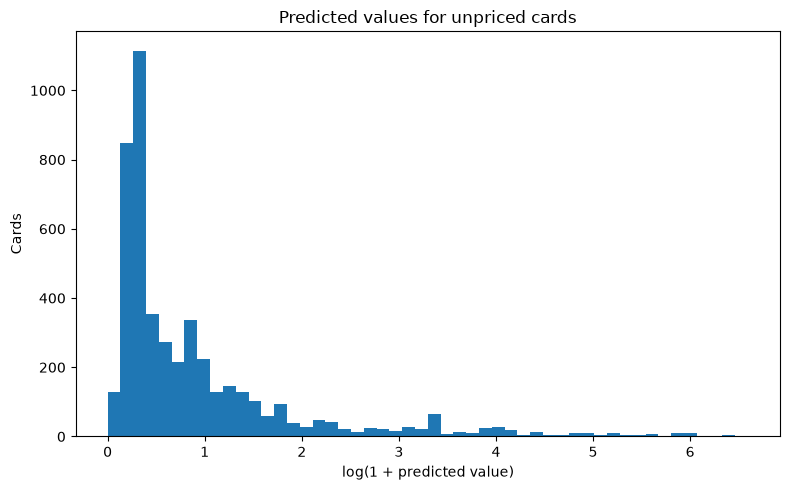

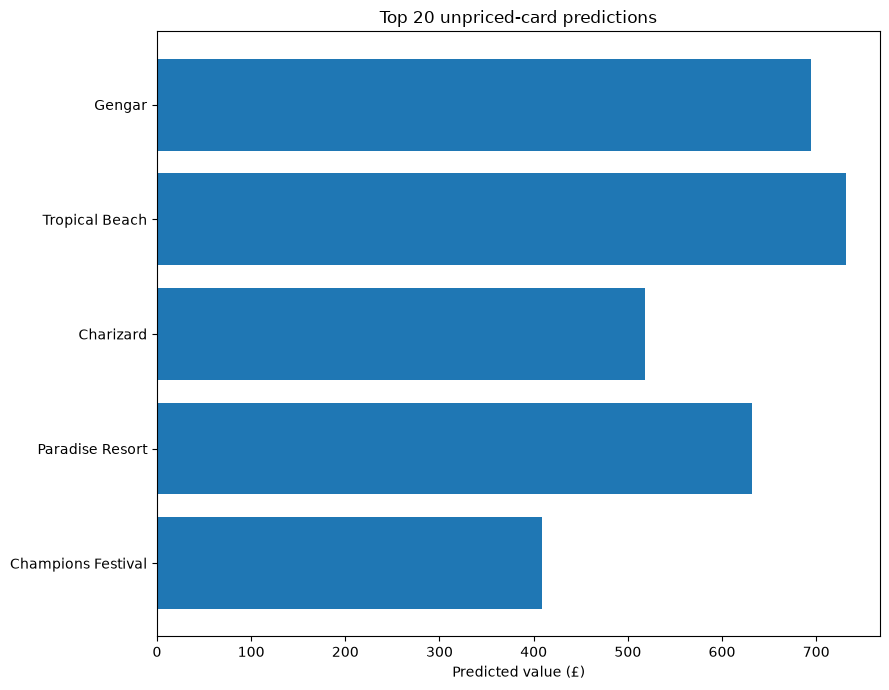

In [5]:
result.to_csv(PROCESSED_DIR / "pokemon_unpriced_card_predictions_lightgbm.csv", index=False, encoding="utf-8-sig")
result.to_csv(TABLES_DIR / "unpriced_card_predictions.csv", index=False, encoding="utf-8-sig")
result.head(100).to_csv(TABLES_DIR / "top_100_unpriced_predictions.csv", index=False, encoding="utf-8-sig")
summary.to_csv(TABLES_DIR / "unpriced_prediction_summary.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(result["predicted_value"]), bins=50)
plt.xlabel("log(1 + predicted value)")
plt.ylabel("Cards")
plt.title("Predicted values for unpriced cards")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "unpriced_value_distribution.png", dpi=200)
plt.show()

plot_data = result.head(20).copy()
plt.figure(figsize=(9, 7))
plt.barh(plot_data["Card Name"][::-1].str.slice(0, 45), plot_data["predicted_value"][::-1])
plt.xlabel("Predicted value (£)")
plt.title("Top 20 unpriced-card predictions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top20_unpriced_predictions.png", dpi=200)
plt.show()